# Germán Cousillas Martínez

$\huge{\text{Ejercicio 1}}$

## Apartado 1: Zeta de Riemann

In [16]:
import numpy as np
from gaussxw import gaussxwab

s, w = gaussxwab(1000,0,1)


def zeta(z):
    f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)
    g = lambda s: 1/(1-s)**2 * f(s/(1-s))
    I = np.sum(w*g(s))
    
    return 1/(z-1)+1/2+2*I

print(zeta(2))
print(np.pi**2/6)

1.6449340668482264
1.6449340668482264


/tmp/ipykernel_7992/2849233315.py:8: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


In [17]:
gamma_teo = 0.5772156649

eps_ = np.linspace(1e-9, 1e-2, 1000)

eps_opt = 1e-2
gamma_opt = 1
err=1

for eps in eps_:
    gamma = (zeta(1+eps)+zeta(1-eps))/2
    err_calc = np.abs(gamma-gamma_teo)
    if err_calc < err:
        err = err_calc
        eps_opt = eps
        gamma_opt = gamma

/tmp/ipykernel_7992/2849233315.py:8: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


In [18]:
print(eps_opt)
print(gamma_opt)
print(gamma_teo)

8.008107207207209e-05
0.5772156648708915
0.5772156649


In [19]:
# Estudiamos ahora el mismo límite sin el polo
zeta_sin_polo = lambda z: zeta(z)-1/(z-1)

gamma_teo = 0.5772156649

eps_ = np.linspace(1e-9, 1e-2, 1000)

eps_opt = 1e-2
gamma_opt = 1
err=1

for eps in eps_:
    gamma = (zeta_sin_polo(1+eps)+zeta_sin_polo(1-eps))/2
    err_calc = np.abs(gamma-gamma_teo)
    if err_calc < err:
        err = err_calc
        eps_opt = eps
        gamma_opt = gamma

/tmp/ipykernel_7992/2849233315.py:8: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


In [20]:
print(eps_opt)
print(gamma_opt)
print(gamma_teo) # Podemos coger eps más pequeño porque prescindimos del error de redondeo asociado al polo

3.003102702702703e-05
0.5772156648999953
0.5772156649


$\huge{\text{Ejercicio 2}}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab

s, w = gaussxwab(1000,0,1)


def zeta(z):
    f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)
    g = lambda s: 1/(1-s)**2 * f(s/(1-s))
    I = np.sum(w*g(s))
    
    return 1/(z-1)+1/2+2*I

zeta=np.vectorize(zeta)

/tmp/ipykernel_9110/2761692829.py:9: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


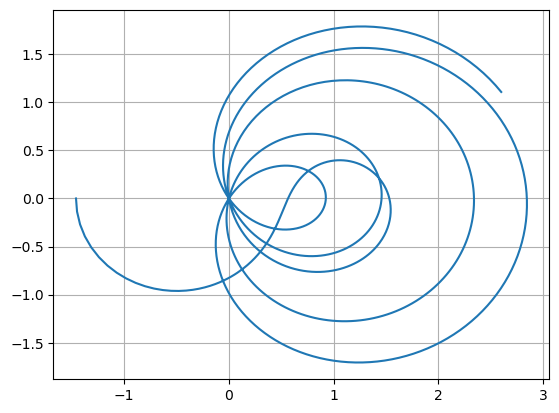

In [21]:
z = 1/2+1j*np.linspace(0,35,1000)

vals = zeta(z) # No quiero integrar lo mismo 2 veces

plt.plot(np.real(vals), np.imag(vals))
plt.grid()
plt.show()

In [3]:
def razon_aurea(f, x1, x4, tol):
    z = (1+np.sqrt(5))/2
    
    x2 = x4 - (x4-x1)/z
    x3 = x1 + (x4-x1)/z
    
    err = 1.0
    
    while err > tol:
        if f(x2) < f(x3): # Vamos en el buen camino si vamos hacia la izq.
            x4 = x3
            x3 = x2
            x2 = x4 - (x4-x1)/z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4-x1)/z
        err = np.abs(x4-x1)
    return (x1+x4)/2

/tmp/ipykernel_9110/2761692829.py:9: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


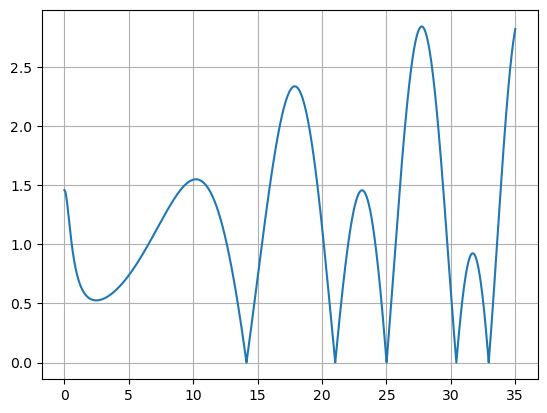

In [10]:
# Hemos transformado así el problema de hallar los 0s de la zeta de Riemann en un problema de minimización
# (aprovechando que el valor mínimo que puede adoptar el módulo de una función compleja es 0)


f = lambda n: np.abs(zeta(1/2+1j*n))
n = np.linspace(0,35,10000)

plt.plot(n, f(n))
plt.grid()
plt.show()

In [13]:
n1 = razon_aurea(f, 13,15,1e-6)
n2 = razon_aurea(f, 20,22,1e-6)
n3 = razon_aurea(f, 24,25.5,1e-6)
n4 = razon_aurea(f, 30,31,1e-6)
n5 = razon_aurea(f, 32.5,34,1e-6)

print(f"""Primeros 5 ceros de la función de Riemann:
z_1 = {1/2+1j*n1}
z_2 = {1/2+1j*n2}
z_3 = {1/2+1j*n3}
z_4 = {1/2+1j*n4}
z_5 = {1/2+1j*n5}""")

/tmp/ipykernel_9110/2761692829.py:9: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


Primeros 5 ceros de la función de Riemann:
z_1 = (0.5+14.134725214488244j)
z_2 = (0.5+21.02203961153613j)
z_3 = (0.5+25.0108576139584j)
z_4 = (0.5+30.424875951751716j)
z_5 = (0.5+32.93506610039666j)


/tmp/ipykernel_9110/2761692829.py:9: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.sin(z*np.arctan(x)) / (1+x**2)**(z/2) / (np.exp(2*np.pi*x)-1)


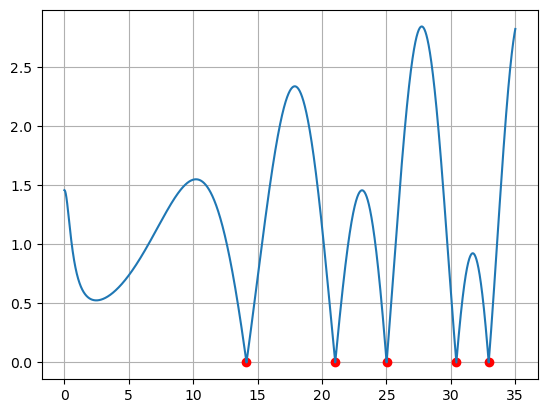

In [12]:
plt.plot(n1, f(n1), "ro")
plt.plot(n2, f(n2), "ro")
plt.plot(n3, f(n3), "ro")
plt.plot(n4, f(n4), "ro")
plt.plot(n5, f(n5), "ro")
plt.plot(n, f(n))
plt.grid()
plt.show()

$\huge{\text{Ejercicio 3}}$

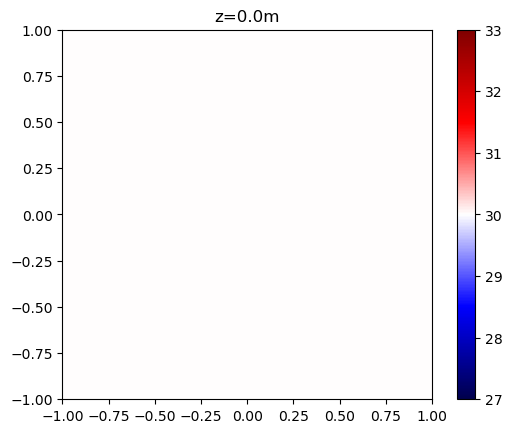

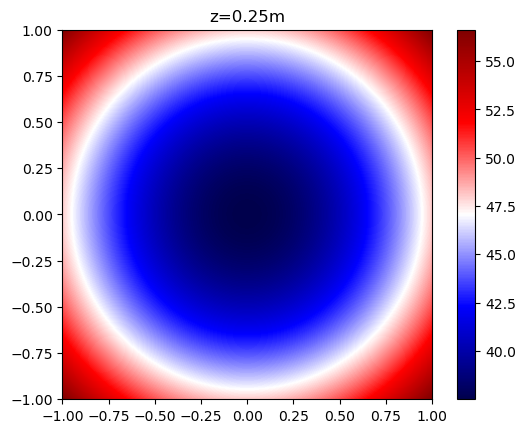

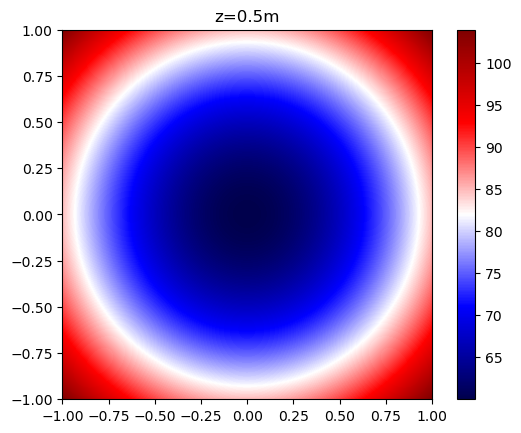

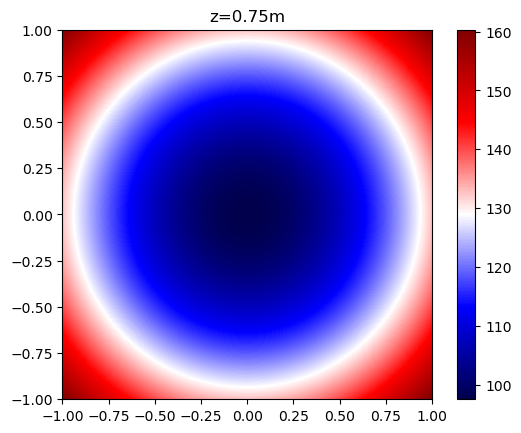

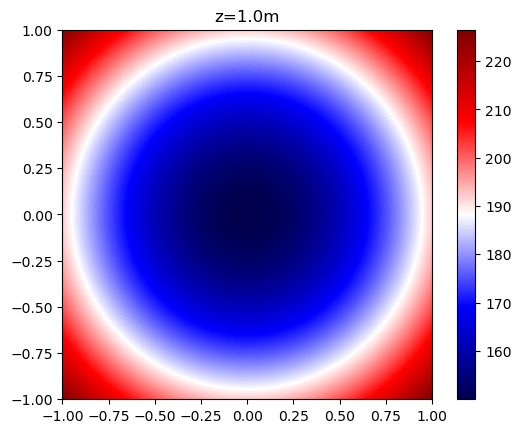

In [11]:
import numpy as np
import matplotlib.pyplot as plt

B0=30
L=2

x = y = np.linspace(-L/2,L/2,1000)
X, Y = np.meshgrid(x, y)

Bx = lambda x, y, z: -16*x*B0*z/L**2
By = lambda x, y, z: -16*y*B0*z/L**2
Bz = lambda x, y, z: B0*(1+16*z**2/L**2)

zs = [0.0,0.25,0.5,0.75,1.0]

for z0 in zs:
    mod = np.sqrt(Bx(X, Y, z0)**2+By(X, Y, z0)**2+Bz(X, Y, z0)**2)
    plt.title(f"z={z0}m")
    plt.imshow(mod, extent=[-L/2,L/2,-L/2,L/2], cmap="seismic")
    plt.colorbar()
    plt.show()

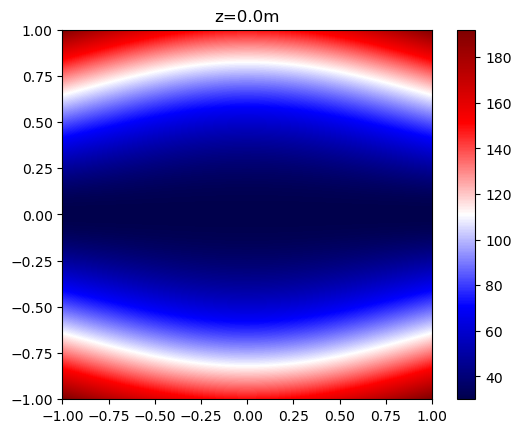

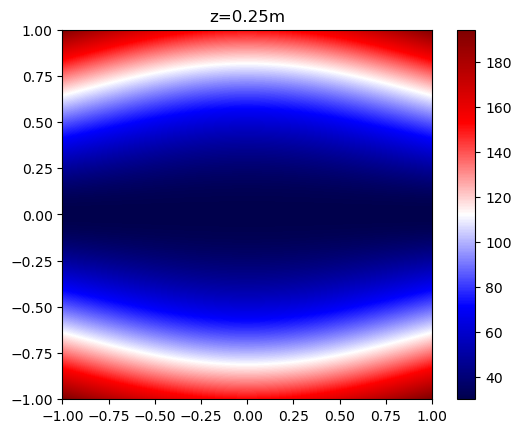

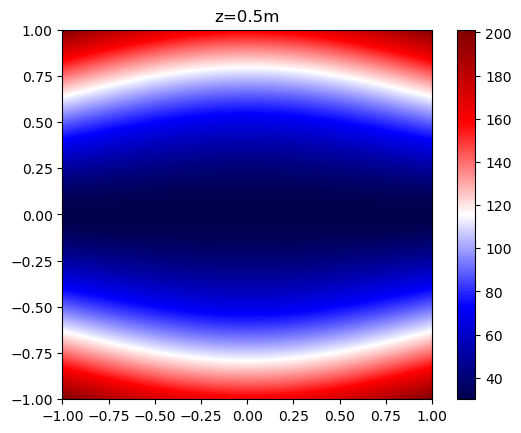

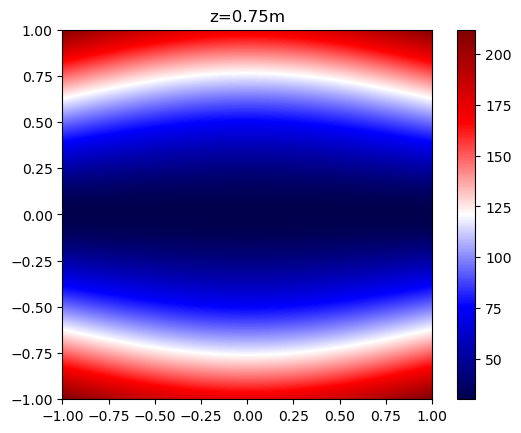

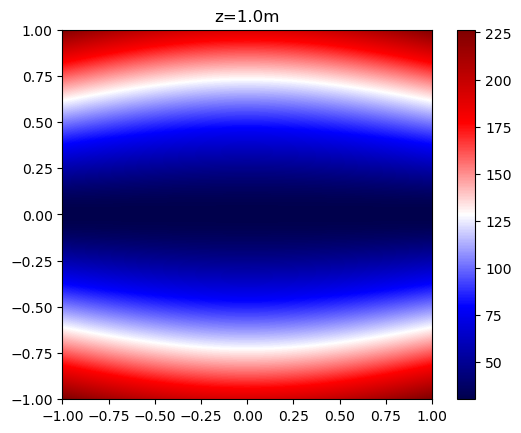

In [1]:
import numpy as np
import matplotlib.pyplot as plt

B0=30
L=2

x = z = np.linspace(-L/2,L/2,1000)
X, Z = np.meshgrid(x, z)

Bx = lambda x, y, z: -16*x*B0*z/L**2
By = lambda x, y, z: -16*y*B0*z/L**2
Bz = lambda x, y, z: B0*(1+16*z**2/L**2)

ys = [0.0,0.25,0.5,0.75,1.0]

for y0 in ys:
    mod = np.sqrt(Bx(X, y0, Z)**2+By(X, y0, Z)**2+Bz(X, y0, Z)**2)
    plt.title(f"z={y0}m")
    plt.imshow(mod, extent=[-L/2,L/2,-L/2,L/2], cmap="seismic")
    plt.colorbar()
    plt.show()

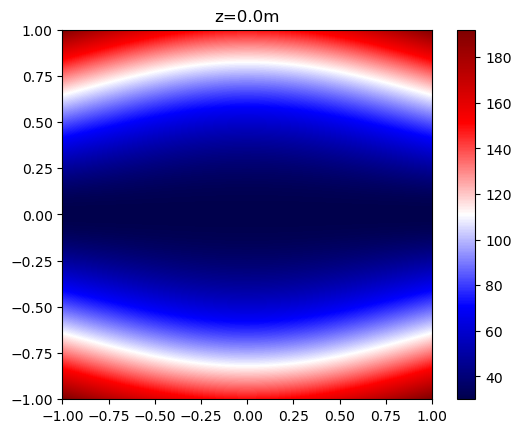

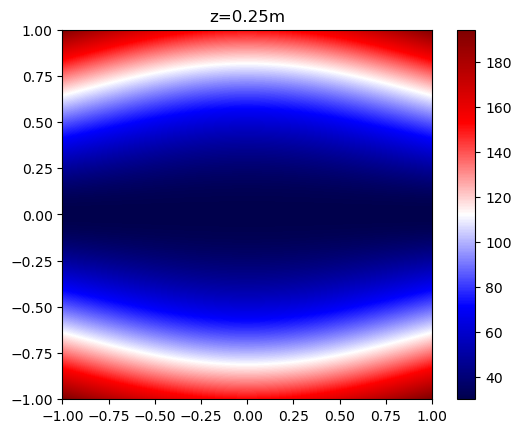

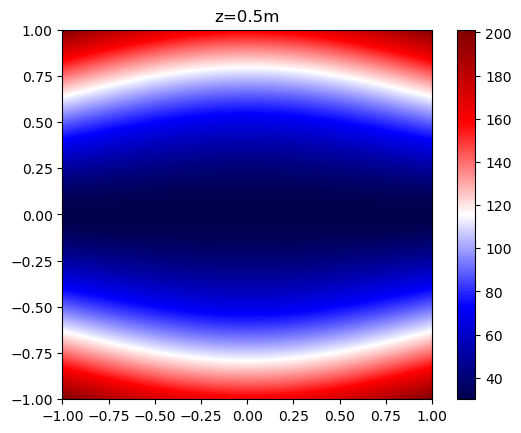

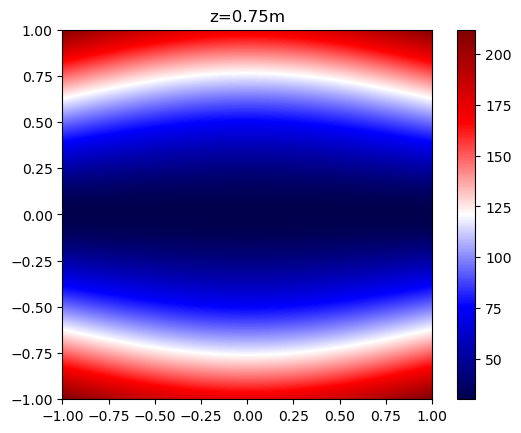

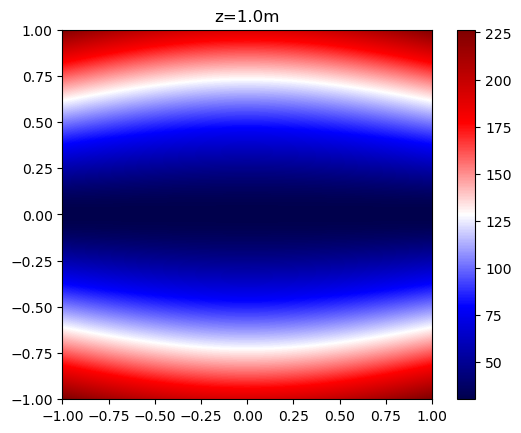

In [2]:
import numpy as np
import matplotlib.pyplot as plt

B0=30
L=2

y = z = np.linspace(-L/2,L/2,1000)
Y, Z = np.meshgrid(y, z)

Bx = lambda x, y, z: -16*x*B0*z/L**2
By = lambda x, y, z: -16*y*B0*z/L**2
Bz = lambda x, y, z: B0*(1+16*z**2/L**2)

xs = [0.0,0.25,0.5,0.75,1.0]

for x0 in xs:
    mod = np.sqrt(Bx(x0, Y, Z)**2+By(x0, Y, Z)**2+Bz(x0, Y, Z)**2)
    plt.title(f"z={x0}m")
    plt.imshow(mod, extent=[-L/2,L/2,-L/2,L/2], cmap="seismic")
    plt.colorbar()
    plt.show()

**Comprobamos que se cumple ley de Gauss**

$$\vec \nabla \cdot \vec F = \frac{\partial F_x}{\partial x} + \frac{\partial F_y}{\partial y} + \frac{\partial F_z}{\partial z}$$

In [17]:
N=100000
x = y = z = np.linspace(-L/2,L/2,N)
a = L/N

derx = (Bx(x+a, y, z)-Bx(x-a, y, z))/(2*a)
dery = (By(x, y+a, z)-By(x, y-a, z))/(2*a)
derz = (Bz(x, y, z+a)-Bz(x, y, z-a))/(2*a)

div = np.sum(derx+dery+derz)
print(div)

3.22268788677596e-08


$\huge{\text{Ejercicio 4}}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

B0=30
L=2

y = z = np.linspace(-L/2,L/2,1000)
Y, Z = np.meshgrid(y, z)

Bx = lambda x, y, z: -16*x*B0*z/L**2
By = lambda x, y, z: -16*y*B0*z/L**2
Bz = lambda x, y, z: B0*(1+16*z**2/L**2)

In [2]:
def get_angle(v1, v2):
    return np.arccos(np.dot(v1, v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)))

def F(r):
    x, y, z, vx, vy, vz = r
    v = np.array([vx, vy, vz])
    B = np.array([Bx(x, y, z), By(x, y, z), Bz(x, y, z)])
    F_L = np.cross(v, B)
    
    return np.array([vx, vy, vz, F_L[0], F_L[1], F_L[2]], float)

r = np.array([0,0,-1,1/2,1/2,1/np.sqrt(2)])
B_init = np.array([Bx(r[0], r[1], r[2]), By(r[0], r[1], r[2]), Bz(r[0], r[1], r[2])])
v_perp = np.linalg.norm(r[3:])*np.sin(get_angle(r[3:], B_init))
mu = 1/2*v_perp**2/np.linalg.norm(B_init)

xp=[]
yp=[]
zp=[]
mus = []

t=0
tp=[]

d = 1e-10
N=110

H = 0.0001
tol = H*d



while np.all(np.abs(r[:3])<=1):
    x, y, z, vx, vy, vz = r
    xp.append(x)
    yp.append(y)
    zp.append(z)
    tp.append(t)
    
    v = np.array([vx, vy, vz])
    B = np.array([Bx(x, y, z), By(x, y, z), Bz(x, y, z)])
    v_perp = np.linalg.norm(v)*np.sin(get_angle(v, B))
    
    mu = 1/2*v_perp**2/np.linalg.norm(B)
    mus.append(mu)
    
    
    # 1. R11 con punto medio modificado
    n = 1
    r_med = r+H/2*F(r)
    r2 = r + H*F(r_med)

    R1 = np.empty([1, 6], float)
    R1[0] = 1/2*(r_med+r2+H/2*F(r2))
    
    # 2. Ahora vamos incrementando el número de pasos en 1 cada vez hasta que lleguemos a tol.
    err = 2*H*d # cogemos este error para asegurarnos de que el while se ejecuta al menos 1 vez, porque tol es precisamente H*d
    while err > tol:
        n+=1
        h=H/n
        r_med = r+h/2*F(r)
        r2 = r + h*F(r_med)
        
        for i in range(n-1):
            r_med+=h*F(r2)
            r2+=h*F(r_med)
            
        # 3. Extrapolación de Richardson hasta completar la fila
        R2 = R1
        
        R1 = np.empty([n,6], float)
        R1[0] = 1/2*(r_med+r2+h/2*F(r2))
        for m in range(1, n):
            eps = (R1[m-1]-R2[m-1])/((n/(n-1))**(2*m)-1)
            R1[m] = R1[m-1]+eps
        err = np.sqrt(eps[3]**2+eps[4]**2+eps[5]**2)
    r = R1[n-1]
    t+=H

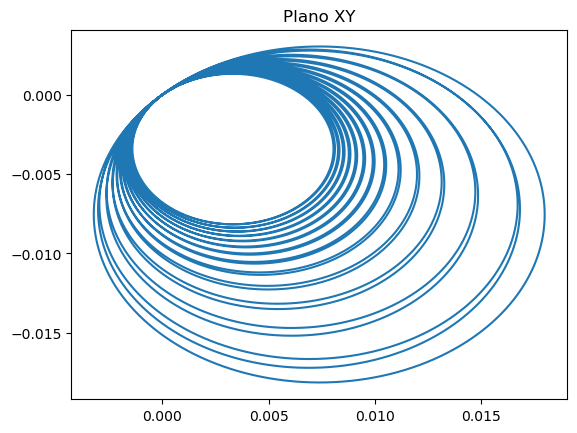

In [3]:
plt.title("Plano XY")
plt.plot(xp, yp)
plt.show()

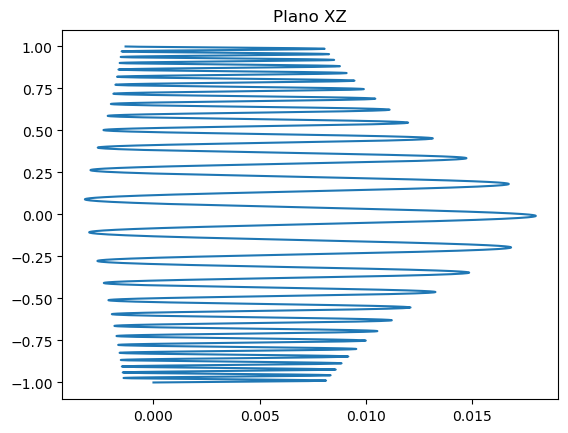

In [4]:
plt.title("Plano XZ")
plt.plot(xp, zp)
plt.show()

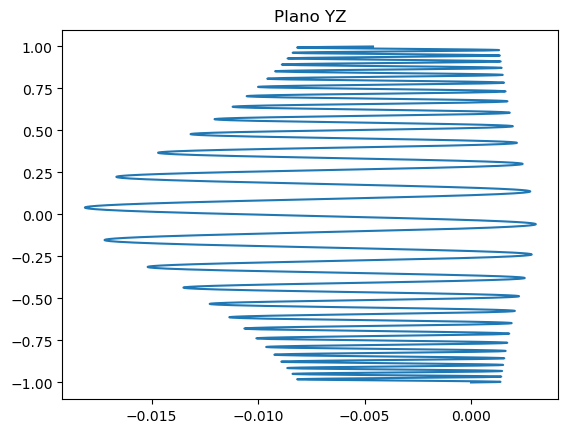

In [5]:
plt.title("Plano YZ")
plt.plot(yp, zp)
plt.show()

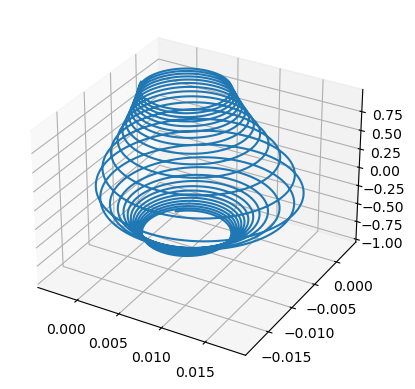

In [6]:
ax = plt.figure().add_subplot(projection="3d")
ax.plot(xp, yp, zp)
plt.show()

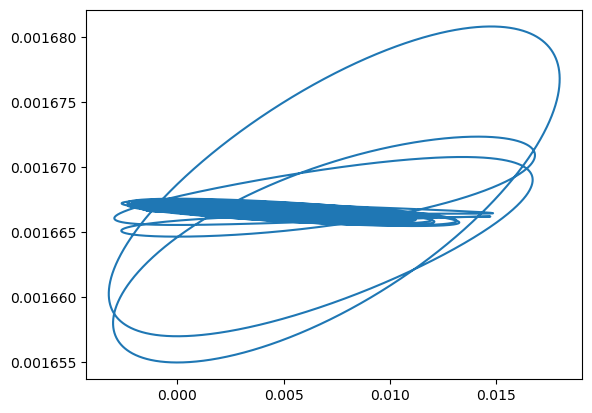

In [11]:
plt.plot(xp, mus)
plt.show()